In [2]:
import numpy as np 
import pandas as pd

In [3]:
stores = pd.read_csv('dim_stores.csv')
campaigns = pd.read_csv('dim_campaigns.csv')
products = pd.read_csv('dim_products.csv')
facts = pd.read_csv('fact_events.csv')

In [4]:
stores.head()

,store_id,city
0,STTRV-0,Trivandrum
1,STMDU-3,Madurai
2,STHYD-6,Hyderabad
3,STVSK-1,Visakhapatnam
4,STCBE-3,Coimbatore


In [5]:
campaigns.head()

,campaign_id,campaign_name,start_date,end_date
0,CAMP_DIW_01,Diwali,12-11-2023,18-11-2023
1,CAMP_SAN_01,Sankranti,10-01-2024,16-01-2024


In [6]:
products.head()

,product_code,product_name,category
0,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples
1,P02,Atliq_Sonamasuri_Rice (10KG),Grocery & Staples
2,P03,Atliq_Suflower_Oil (1L),Grocery & Staples
3,P04,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples
4,P05,Atliq_Scrub_Sponge_For_Dishwash,Home Care


In [7]:
facts.head()

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo)
0,7f650b,STCBE-2,CAMP_SAN_01,P11,190,50% OFF,34,52
1,a21f91,STBLR-8,CAMP_DIW_01,P03,156,25% OFF,393,322
2,78bc80,STVJD-0,CAMP_SAN_01,P07,300,BOGOF,22,85
3,a1503f,STCBE-1,CAMP_DIW_01,P15,3000,500 Cashback,329,1000
4,1091cf,STBLR-6,CAMP_DIW_01,P05,55,25% OFF,108,93


In [10]:
stores.columns

Index(['store_id', 'city'], dtype='object')

In [9]:
campaigns.columns

Index(['campaign_id', 'campaign_name', 'start_date', 'end_date'], dtype='object')

In [8]:
products.columns

Index(['product_code', 'product_name', 'category'], dtype='object')

In [11]:
facts.columns

Index(['event_id', 'store_id', 'campaign_id', 'product_code', 'base_price',
       'promo_type', 'quantity_sold(before_promo)',
       'quantity_sold(after_promo)'],
      dtype='object')

In [12]:
master_df = facts.merge(
    products,
    on='product_code',
    how='left'
)

In [13]:
master_df = master_df.merge(
    stores,
    on='store_id',
    how='left'
)

In [14]:
master_df = master_df.merge(
    campaigns,
    on='campaign_id',
    how='left'
)

In [16]:
master_df.head()

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo),product_name,category,city,campaign_name,start_date,end_date
0,7f650b,STCBE-2,CAMP_SAN_01,P11,190,50% OFF,34,52,Atliq_Doodh_Kesar_Body_Lotion (200ML),Personal Care,Coimbatore,Sankranti,10-01-2024,16-01-2024
1,a21f91,STBLR-8,CAMP_DIW_01,P03,156,25% OFF,393,322,Atliq_Suflower_Oil (1L),Grocery & Staples,Bengaluru,Diwali,12-11-2023,18-11-2023
2,78bc80,STVJD-0,CAMP_SAN_01,P07,300,BOGOF,22,85,Atliq_Curtains,Home Care,Vijayawada,Sankranti,10-01-2024,16-01-2024
3,a1503f,STCBE-1,CAMP_DIW_01,P15,3000,500 Cashback,329,1000,Atliq_Home_Essential_8_Product_Combo,Combo1,Coimbatore,Diwali,12-11-2023,18-11-2023
4,1091cf,STBLR-6,CAMP_DIW_01,P05,55,25% OFF,108,93,Atliq_Scrub_Sponge_For_Dishwash,Home Care,Bengaluru,Diwali,12-11-2023,18-11-2023


In [17]:
master_df.shape

(1500, 14)

In [18]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   event_id                     1500 non-null   object
 1   store_id                     1500 non-null   object
 2   campaign_id                  1500 non-null   object
 3   product_code                 1500 non-null   object
 4   base_price                   1500 non-null   int64 
 5   promo_type                   1500 non-null   object
 6   quantity_sold(before_promo)  1500 non-null   int64 
 7   quantity_sold(after_promo)   1500 non-null   int64 
 8   product_name                 1500 non-null   object
 9   category                     1500 non-null   object
 10  city                         1500 non-null   object
 11  campaign_name                1500 non-null   object
 12  start_date                   1500 non-null   object
 13  end_date                     1500

In [20]:
master_df['revenue_before'] = (master_df['base_price'] * master_df['quantity_sold(before_promo)'])

In [21]:
master_df['revenue_after'] = (master_df['base_price'] * master_df['quantity_sold(after_promo)'])

In [23]:
print(master_df['revenue_before'].sum())
print(master_df['revenue_after'].sum())

140701188
347860150


In [24]:
master_df['quantity_change'] = (master_df['quantity_sold(after_promo)'] - master_df['quantity_sold(before_promo)'])

In [25]:
master_df['revenue_change'] = (master_df['revenue_after'] - master_df['revenue_before'])

In [26]:
master_df.head()

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo),product_name,category,city,campaign_name,start_date,end_date,revenue_before,revenue_after,quantity_change,revenue_change
0,7f650b,STCBE-2,CAMP_SAN_01,P11,190,50% OFF,34,52,Atliq_Doodh_Kesar_Body_Lotion (200ML),Personal Care,Coimbatore,Sankranti,10-01-2024,16-01-2024,6460,9880,18,3420
1,a21f91,STBLR-8,CAMP_DIW_01,P03,156,25% OFF,393,322,Atliq_Suflower_Oil (1L),Grocery & Staples,Bengaluru,Diwali,12-11-2023,18-11-2023,61308,50232,-71,-11076
2,78bc80,STVJD-0,CAMP_SAN_01,P07,300,BOGOF,22,85,Atliq_Curtains,Home Care,Vijayawada,Sankranti,10-01-2024,16-01-2024,6600,25500,63,18900
3,a1503f,STCBE-1,CAMP_DIW_01,P15,3000,500 Cashback,329,1000,Atliq_Home_Essential_8_Product_Combo,Combo1,Coimbatore,Diwali,12-11-2023,18-11-2023,987000,3000000,671,2013000
4,1091cf,STBLR-6,CAMP_DIW_01,P05,55,25% OFF,108,93,Atliq_Scrub_Sponge_For_Dishwash,Home Care,Bengaluru,Diwali,12-11-2023,18-11-2023,5940,5115,-15,-825


In [21]:
master_df.groupby('promo_type')[['revenue_before','revenue_after']].sum()

,revenue_before,revenue_after
promo_type,,
25% OFF,9173467,7998603
33% OFF,36540540,52204752
50% OFF,2162951,2872575
500 Cashback,66897000,189540000
BOGOF,25927230,95244220


In [22]:
promo_performance = master_df.groupby('promo_type')[['revenue_before','revenue_after']].sum()

promo_performance['revenue_growth_percent'] = (
    (promo_performance['revenue_after'] - promo_performance['revenue_before'])
    / promo_performance['revenue_before']
) * 100

promo_performance

,revenue_before,revenue_after,revenue_growth_percent
promo_type,,,
25% OFF,9173467,7998603,-12.807197
33% OFF,36540540,52204752,42.868036
50% OFF,2162951,2872575,32.808140
500 Cashback,66897000,189540000,183.331091
BOGOF,25927230,95244220,267.352085


In [23]:
quantity_performance = master_df.groupby('promo_type')[
    ['quantity_sold(before_promo)', 'quantity_sold(after_promo)']
].sum()

quantity_performance['quantity_growth_percent'] = (
    (
        quantity_performance['quantity_sold(after_promo)'] -
        quantity_performance['quantity_sold(before_promo)']
    )
    /
    quantity_performance['quantity_sold(before_promo)']
) * 100

quantity_performance

,quantity_sold(before_promo),quantity_sold(after_promo),quantity_growth_percent
promo_type,,,
25% OFF,44007,38290,-12.991115
33% OFF,63321,90576,43.042593
50% OFF,21243,28174,32.627218
500 Cashback,22299,63180,183.331091
BOGOF,58180,215253,269.977656


In [24]:
category_performance = master_df.groupby('category')[
    ['revenue_before', 'revenue_after']
].sum()

category_performance['growth_percent'] = (
    (
        category_performance['revenue_after'] -
        category_performance['revenue_before']
    )
    /
    category_performance['revenue_before']
) * 100

category_performance.sort_values(
    by='growth_percent',
    ascending=False
)

,revenue_before,revenue_after,growth_percent
category,,,
Home Appliances,9483110,34633500,265.212467
Combo1,66897000,189540000,183.331091
Home Care,8856985,24944175,181.632802
Grocery & Staples,52991852,95615960,80.435211
Personal Care,2472241,3126515,26.464815


In [25]:
category_promo = master_df.groupby(
    ['category', 'promo_type']
)[['revenue_before', 'revenue_after']].sum()

category_promo['growth_percent'] = (
    (
        category_promo['revenue_after'] -
        category_promo['revenue_before']
    )
    /
    category_promo['revenue_before']
) * 100

category_promo.sort_values(
    by='growth_percent',
    ascending=False
)

,,revenue_before,revenue_after,growth_percent
category,promo_type,,,
Grocery & Staples,BOGOF,10064950,37796600,275.526952
Home Appliances,BOGOF,9483110,34633500,265.212467
Home Care,BOGOF,6379170,22814120,257.634614
Combo1,500 Cashback,66897000,189540000,183.331091
Grocery & Staples,33% OFF,36540540,52204752,42.868036
Personal Care,50% OFF,2162951,2872575,32.808140
Grocery & Staples,25% OFF,6386362,5614608,-12.084407
Home Care,25% OFF,2477815,2130055,-14.034946
Personal Care,25% OFF,309290,253940,-17.895826


In [26]:
city_performance = master_df.groupby('city')[
    ['revenue_before', 'revenue_after']
].sum()

city_performance['growth_percent'] = (
    (
        city_performance['revenue_after'] -
        city_performance['revenue_before']
    )
    /
    city_performance['revenue_before']
) * 100

city_performance.sort_values(
    by='growth_percent',
    ascending=False
)

,revenue_before,revenue_after,growth_percent
city,,,
Madurai,10331552,26682384,158.261140
Bengaluru,32943279,83707621,154.096203
Chennai,26286454,66787456,154.075563
Vijayawada,3587937,9006240,151.014441
Coimbatore,12235954,30404660,148.486223
Trivandrum,3201786,7867846,145.733038
Mysuru,12946287,31801764,145.643898
Hyderabad,22678681,53519028,135.988275
Mangalore,5034816,11774495,133.861476


In [27]:
product_performance = master_df.groupby('product_name')[
    ['revenue_before', 'revenue_after']
].sum()

product_performance['growth_percent'] = (
    (
        product_performance['revenue_after'] -
        product_performance['revenue_before']
    )
    /
    product_performance['revenue_before']
) * 100

product_performance.sort_values(
    by='growth_percent',
    ascending=False
).head(10)

,revenue_before,revenue_after,growth_percent
product_name,,,
Atliq_waterproof_Immersion_Rod,6597360,24158700,266.187384
Atliq_High_Glo_15W_LED_Bulb,2885750,10474800,262.983626
Atliq_Double_Bedsheet_set,5001570,17919020,258.267904
Atliq_Curtains,1377600,4895100,255.335366
Atliq_Home_Essential_8_Product_Combo,66897000,189540000,183.331091
Atliq_Farm_Chakki_Atta (1KG),10851800,29100500,168.162885
Atliq_Suflower_Oil (1L),5599512,14310708,155.570628
Atliq_Masoor_Dal (1KG),4478880,6422652,43.398618
Atliq_Sonamasuri_Rice (10KG),32061660,45782100,42.793916


In [28]:
product_performance.sort_values(
    by='growth_percent',
    ascending=True
).head(10)

,revenue_before,revenue_after,growth_percent
product_name,,,
Atliq_Fusion_Container_Set_of_3,2160905,1855880,-14.115614
Atliq_Scrub_Sponge_For_Dishwash,316910,274175,-13.484901
Atliq_Body_Milk_Nourishing_Lotion (120ML),601270,671830,11.735161
Atliq_Cream_Beauty_Bathing_Soap (125GM),393625,483145,22.742458
Atliq_Lime_Cool_Bathing_Bar (125GM),478516,637360,33.195128
Atliq_Doodh_Kesar_Body_Lotion (200ML),998830,1334180,33.574282
Atliq_Sonamasuri_Rice (10KG),32061660,45782100,42.793916
Atliq_Masoor_Dal (1KG),4478880,6422652,43.398618
Atliq_Suflower_Oil (1L),5599512,14310708,155.570628


In [29]:
master_df.to_csv('atliq_master_analysis.csv', index=False)

VISUALIZATIONS

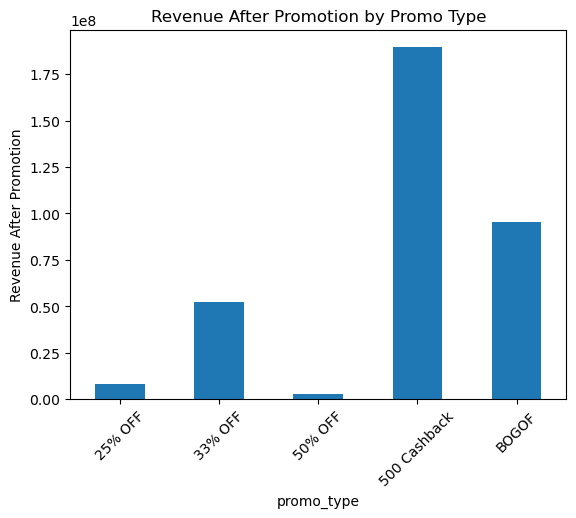

In [30]:
import matplotlib.pyplot as plt

promo_performance['revenue_after'].plot(kind='bar')

plt.title('Revenue After Promotion by Promo Type')
plt.ylabel('Revenue After Promotion')
plt.xticks(rotation=45)

plt.show()

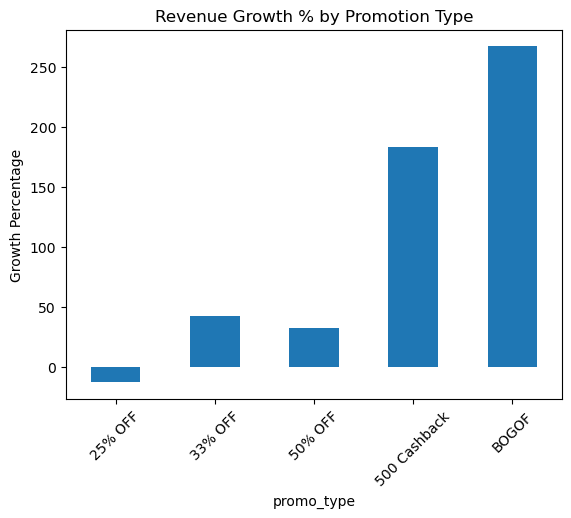

In [31]:
promo_performance['revenue_growth_percent'].plot(kind='bar')

plt.title('Revenue Growth % by Promotion Type')
plt.ylabel('Growth Percentage')
plt.xticks(rotation=45)

plt.show()

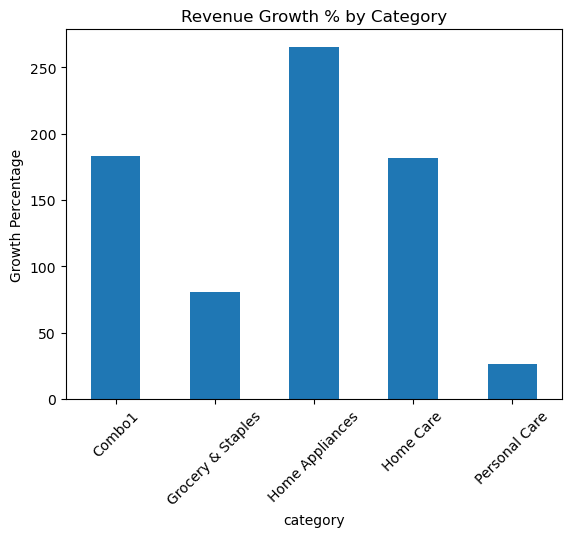

In [32]:
category_performance['growth_percent'].plot(kind='bar')

plt.title('Revenue Growth % by Category')
plt.ylabel('Growth Percentage')
plt.xticks(rotation=45)

plt.show()

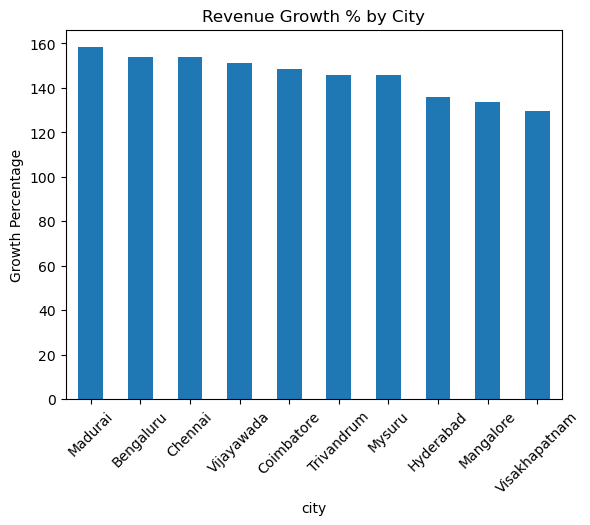

In [33]:
city_performance['growth_percent'].sort_values(
    ascending=False
).plot(kind='bar')

plt.title('Revenue Growth % by City')
plt.ylabel('Growth Percentage')
plt.xticks(rotation=45)

plt.show()

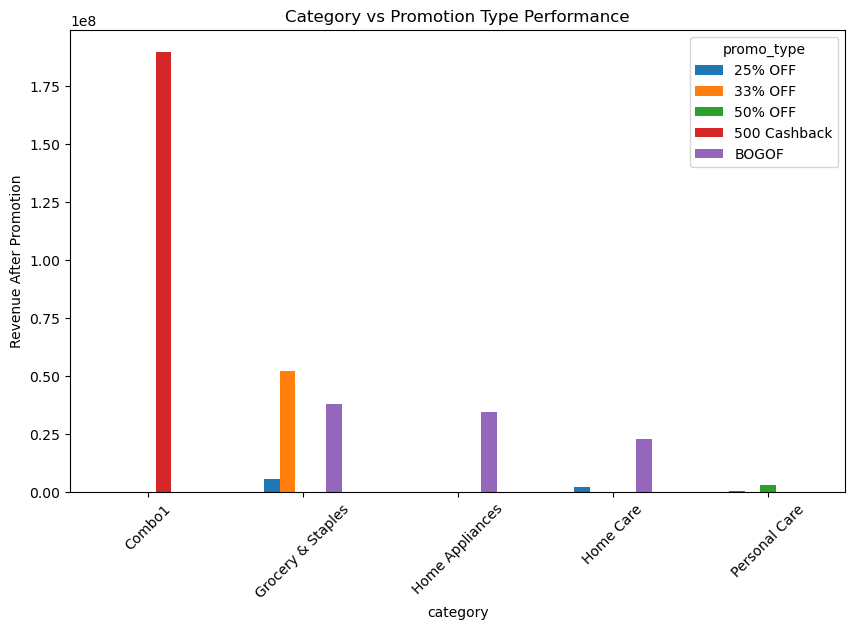

In [34]:
pivot_table = master_df.pivot_table(
    values='revenue_after',
    index='category',
    columns='promo_type',
    aggfunc='sum'
)

pivot_table.plot(kind='bar', figsize=(10,6))

plt.title('Category vs Promotion Type Performance')
plt.ylabel('Revenue After Promotion')
plt.xticks(rotation=45)

plt.show()

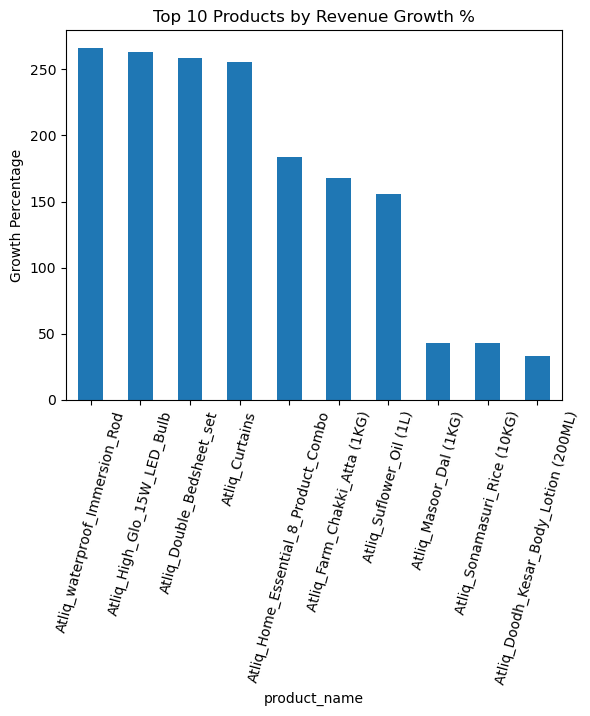

In [35]:
top_products = product_performance.sort_values(
    by='growth_percent',
    ascending=False
).head(10)

top_products['growth_percent'].plot(
    kind='bar'
)

plt.title('Top 10 Products by Revenue Growth %')
plt.ylabel('Growth Percentage')
plt.xticks(rotation=75)

plt.show()

In [36]:
summary_metrics = {
    'Total Revenue Before': master_df['revenue_before'].sum(),
    'Total Revenue After': master_df['revenue_after'].sum(),
    'Total Revenue Growth %': (
        (
            master_df['revenue_after'].sum() -
            master_df['revenue_before'].sum()
        )
        /
        master_df['revenue_before'].sum()
    ) * 100,
    
    'Total Quantity Before': master_df['quantity_sold(before_promo)'].sum(),
    'Total Quantity After': master_df['quantity_sold(after_promo)'].sum()
}

summary_metrics

{'Total Revenue Before': 140701188,
 'Total Revenue After': 347860150,
 'Total Revenue Growth %': 147.23327140635087,
 'Total Quantity Before': 209050,
 'Total Quantity After': 435473}

# Key Business Insights

1. BOGOF promotions delivered the highest revenue and quantity growth, making them the most effective overall promotion strategy.

2. 25% OFF promotions negatively impacted both revenue and quantity sold, indicating poor customer response.

3. Home Appliances and Combo bundles showed the strongest growth during promotional campaigns.

4. Bengaluru, Chennai, and Madurai demonstrated the highest revenue growth among all cities.

5. Products like Atliq Waterproof Immersion Rod and LED Bulbs experienced exceptional promotional uplift.

6. Certain Home Care and Personal Care products underperformed despite promotions, suggesting inefficient discount allocation.

In [37]:
master_df.to_csv(
    'atliq_promotion_analysis_final.csv',
    index=False
)